In [2]:
#imporrt libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#load the data
df = pd.read_csv('/content/Sports Supplements.csv')

In [4]:
#preview data
df.head()

,supplement,alt name,"evidence level - score. 0 = no evidence, 1,2 = slight, 3 = conflicting , 4 = promising, 5 = good, 6 = strong",Claimed improved aspect of fitness,fitness category,sport or exercise type tested,OTW,popularity,number of studies examined,number of citations,...,Link to individual study.11,Link to individual study.12,Link to individual study.13,Link to individual study.14,Link to individual study.15,Link to individual study.16,Link to individual study.17,Link to individual study.18,Link to individual study.19,Link to individual study.20
0,AAKG,L-arginine alpha-ketoglutarate,1.0,peak power output,strength–power,weight training,OTW,242,1,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAKG,L-arginine alpha-ketoglutarate,0.0,"body composition, aerobic capacity, muscle end...","fat burning–muscle building, aerobic–endurance",weight training,NaN,242,1,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Baking soda,"Bicarbonate of soda, sodium bicarbonate, NaHCO3",5.0,high-intensity performance,anaerobic–high-intensity,"rowing, cycling, swimming, running, other",NaN,947,14,140,...,http://onlinelibrary.wiley.com/o/cochrane/clce...,http://onlinelibrary.wiley.com/o/cochrane/clce...,http://onlinelibrary.wiley.com/o/cochrane/clce...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BCAAs,"branched-chain amino acids, leucine, isoleucin...",4.0,fatigue resistance,aerobic–endurance,"cycling, circuit training",NaN,5490,3,660,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BCAAs,"branched-chain amino acids, leucine, isoleucin...",3.0,"aerobic performance, endurance, power","aerobic–endurance, strength–power","cycling, other",NaN,5490,4,660,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#shape of the dataframe
df.shape

(96, 46)

In [6]:
#overview of columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 46 columns):
 #   Column                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                         --------------  -----  
 0   supplement                                                                                                     96 non-null     object 
 1   alt name                                                                                                       51 non-null     object 
 2   evidence level - score. 0 = no evidence, 1,2 = slight, 3 = conflicting , 4 = promising, 5 = good, 6 = strong   96 non-null     float64
 3   Claimed improved aspect of fitness                                                                             96 non-null     object 
 4   fitness category                                    

In [7]:
#missing values
df.isnull().sum()

,0
supplement,0
alt name,45
"evidence level - score. 0 = no evidence, 1,2 = slight, 3 = conflicting , 4 = promising, 5 = good, 6 = strong",0
Claimed improved aspect of fitness,0
fitness category,0
sport or exercise type tested,0
OTW,68
popularity,0
number of studies examined,0
number of citations,0


#Data Cleaning

In [8]:
#Check Missing Values
df.fillna('Unknown', inplace=True)

/tmp/ipykernel_694/2122094874.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('Unknown', inplace=True)


In [9]:
#Check duplicates
df.duplicated().sum()

#Removes duplicates
df = df.drop_duplicates()

In [10]:
#Remove spaces and make columns consistent
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [11]:
#Remove Extra Spaces in Text Columns
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].str.strip()

In [12]:
#Rename Columns
df.rename(columns={
    'product name':'product_name',
    'customer rating':'customer_rating'
}, inplace=True)

#Feature Engineering

In [13]:
# Calculate research success rate
# Convert 'n_positive_studies_/_trials' to numeric, coercing errors to NaN
df['n_positive_studies_/_trials'] = pd.to_numeric(df['n_positive_studies_/_trials'], errors='coerce')

# Calculate the rate, handling potential division by zero or NaN values
df['research_success_rate'] = (
    df['n_positive_studies_/_trials'] /
    df['number_of_studies_examined']
)

# Fill NaN values (e.g., from coercion or division by zero) with 0 for the success rate
df['research_success_rate'] = df['research_success_rate'].fillna(0)

In [14]:
# Convert 'efficacy' to numeric, coercing errors to NaN
df['efficacy'] = pd.to_numeric(df['efficacy'], errors='coerce')
# Fill NaN values in 'efficacy' with 0 for scoring purposes
df['efficacy'] = df['efficacy'].fillna(0)

# Create supplement ranking score
df['supplement_score'] = (
    df['efficacy'] +
    df['popularity'] +
    df['evidence_level_-_score._0_=_no_evidence,_1,2_=_slight,_3_=_conflicting_,_4_=_promising,_5_=_good,_6_=_strong']
)

In [15]:
# Rank supplements based on overall score
df['supplement_rank'] = df['supplement_score'].rank(
    ascending=False
)


df.head()

,supplement,alt_name,"evidence_level_-_score._0_=_no_evidence,_1,2_=_slight,_3_=_conflicting_,_4_=_promising,_5_=_good,_6_=_strong",claimed_improved_aspect_of_fitness,fitness_category,sport_or_exercise_type_tested,otw,popularity,number_of_studies_examined,number_of_citations,...,link_to_individual_study.14,link_to_individual_study.15,link_to_individual_study.16,link_to_individual_study.17,link_to_individual_study.18,link_to_individual_study.19,link_to_individual_study.20,research_success_rate,supplement_score,supplement_rank
0,AAKG,L-arginine alpha-ketoglutarate,1.0,peak power output,strength–power,weight training,OTW,242,1,20,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,1.000000,243.0,88.0
1,AAKG,L-arginine alpha-ketoglutarate,0.0,"body composition, aerobic capacity, muscle end...","fat burning–muscle building, aerobic–endurance",weight training,Unknown,242,1,20,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0.000000,242.0,89.0
2,Baking soda,"Bicarbonate of soda, sodium bicarbonate, NaHCO3",5.0,high-intensity performance,anaerobic–high-intensity,"rowing, cycling, swimming, running, other",Unknown,947,14,140,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0.642857,952.0,64.0
3,BCAAs,"branched-chain amino acids, leucine, isoleucin...",4.0,fatigue resistance,aerobic–endurance,"cycling, circuit training",Unknown,5490,3,660,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,1.000000,5494.0,22.0
4,BCAAs,"branched-chain amino acids, leucine, isoleucin...",3.0,"aerobic performance, endurance, power","aerobic–endurance, strength–power","cycling, other",Unknown,5490,4,660,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0.500000,5493.0,23.0


# EDA(Exploratory Data Analysis)

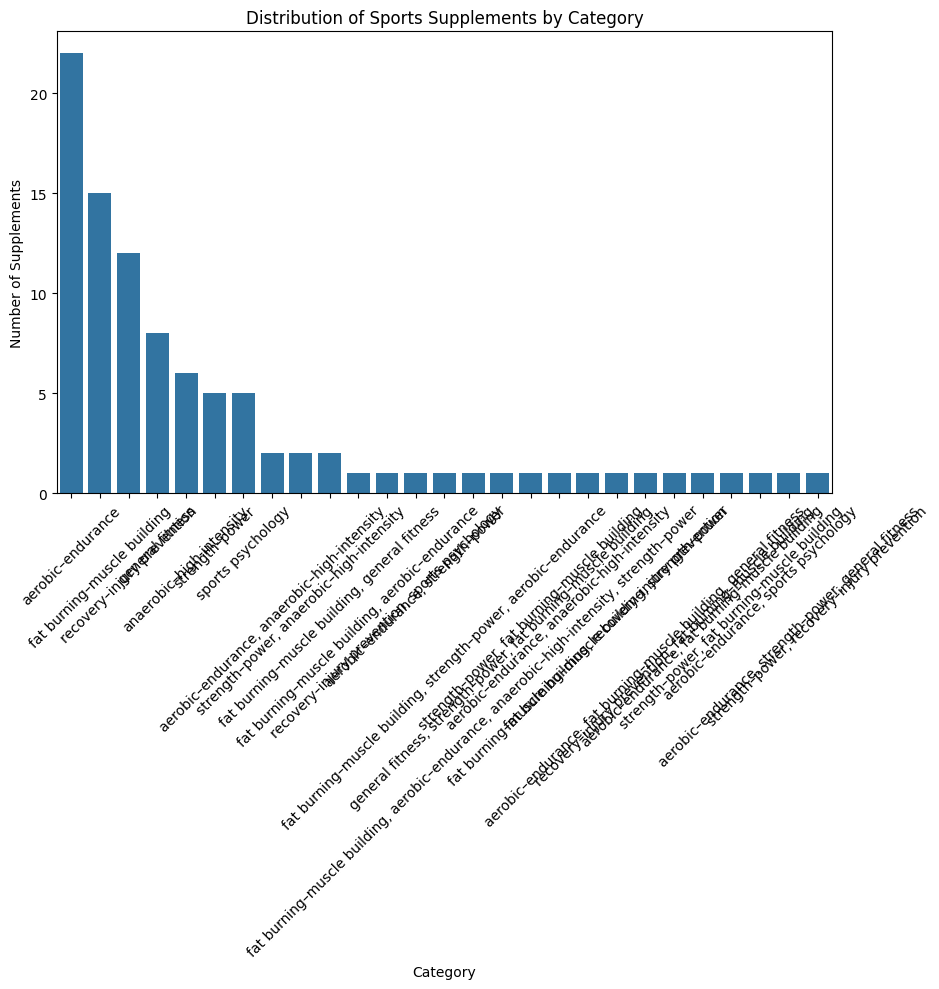

In [21]:
#Count of supplements by category
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='fitness_category',
    order=df['fitness_category'].value_counts().index
)

plt.title('Distribution of Sports Supplements by Category')
plt.xlabel('Category')
plt.ylabel('Number of Supplements')
plt.xticks(rotation=45)
plt.savefig('category_plot.png')
plt.show()

##The analysis shows the distribution of supplements across different categories. Categories with higher counts indicate areas with more product variety and popularity, while categories with fewer supplements may represent more specialized products.

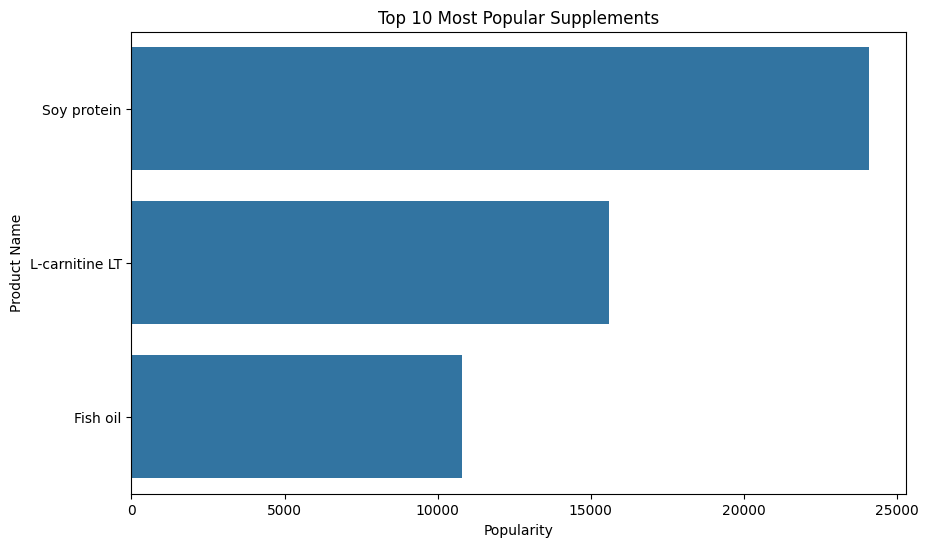

In [22]:
#Top 10 Most Popular Supplements
plt.figure(figsize=(10,6))

sns.barplot(
    data=df.sort_values(by='popularity', ascending=False).head(10),
    x='popularity',
    y='supplement'
)

plt.title('Top 10 Most Popular Supplements')
plt.xlabel('Popularity')
plt.ylabel('Product Name')
plt.savefig('popularity_plot.png')
plt.show()

##The analysis identifies the supplements with the highest popularity scores. These supplements have stronger consumer recognition and market demand compared to others in the dataset.

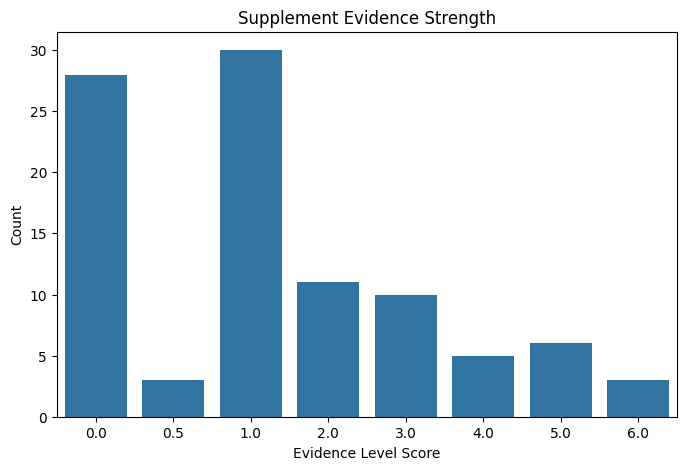

In [18]:
#Evidence Level Analysis
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='evidence_level_-_score._0_=_no_evidence,_1,2_=_slight,_3_=_conflicting_,_4_=_promising,_5_=_good,_6_=_strong'
)

plt.title('Supplement Evidence Strength')
plt.xlabel('Evidence Level Score')
plt.ylabel('Count')
plt.savefig('evidence_level_plot.png')
plt.show()

##The evidence level analysis shows the strength of scientific support behind supplements. Supplements with stronger evidence categories have more reliable research backing, while lower evidence categories require further investigation.

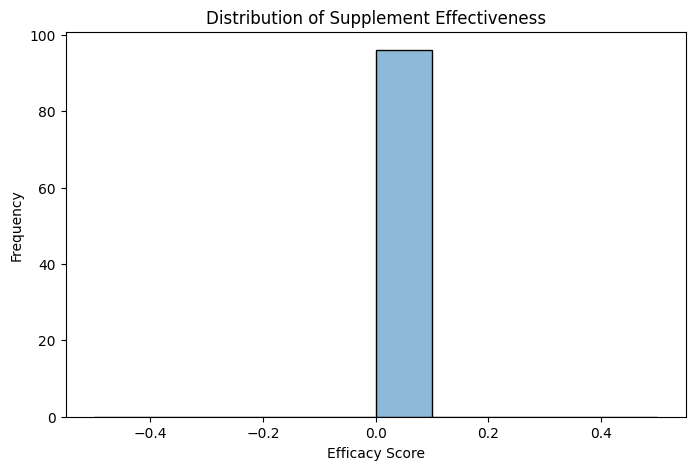

In [23]:
#Efficacy Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['efficacy'],
    bins=10,
    kde=True
)

plt.title('Distribution of Supplement Effectiveness')
plt.xlabel('Efficacy Score')
plt.ylabel('Frequency')
plt.savefig('efficacy_distribution_plot.png')
plt.show()

##The efficacy distribution highlights how supplements vary in effectiveness. A higher concentration of supplements with strong efficacy scores suggests that many products demonstrate measurable benefits, while lower scores indicate limited effectiveness.

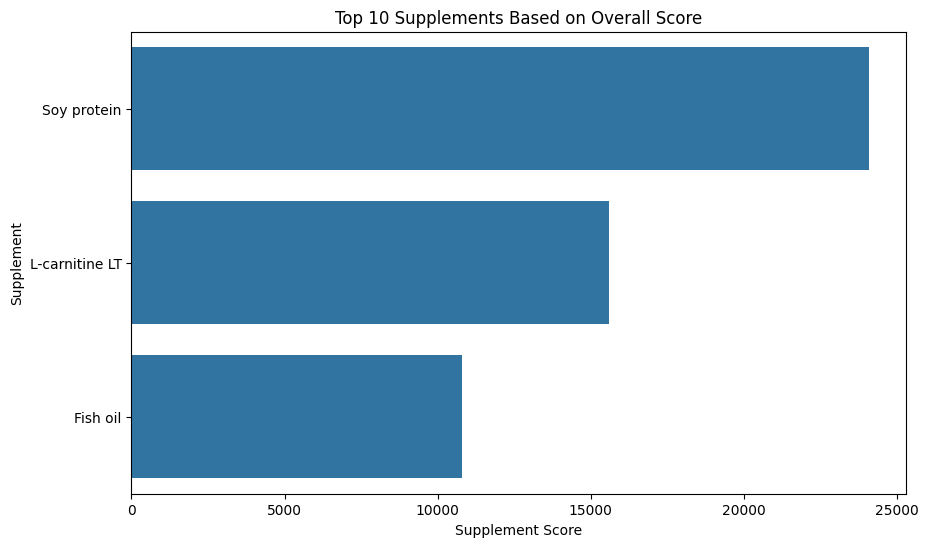

In [24]:
#Top 10 Highest Ranked Supplements
top_ranked = df.sort_values(
    by='supplement_rank'
).head(10)


plt.figure(figsize=(10,6))

sns.barplot(
    data=top_ranked,
    x='supplement_score',
    y='supplement'
)

plt.title('Top 10 Supplements Based on Overall Score')
plt.xlabel('Supplement Score')
plt.ylabel('Supplement')
plt.savefig('top_ranked_plot.png')
plt.show()

##The ranking analysis identifies the best-performing supplements based on combined factors such as effectiveness, popularity, and evidence level. Higher-ranked supplements demonstrate a stronger overall performance compared to others.